# 📈 Notebook 04: Análise Financeira e Event Studies

**NOVO** - Complementa o framework com métricas financeiras  
**Data:** 2026-04-16

## Objetivo

1. **Métricas de Risco-Retorno**: Sharpe, Sortino, Max Drawdown
2. **Event Studies**: Cumulative Abnormal Returns (CAR)
3. **Análise de Volatilidade**: VaR, CVaR

---

In [1]:
"""Setup."""
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sys.path.append(str(Path.cwd().parent / "src"))
from config import config

print("✅ Setup completo")

✅ Setup completo


In [2]:
"""Carregar dados."""
df = pd.read_csv(config.DATA_PROCESSED / "esge_master.csv")

print(f"📊 Dataset: {df.shape}")
print(df.head())

📊 Dataset: (24, 6)
   year  char_count  esg_disclosure_score  close_price        volume  \
0  2001      140594                     4     4.227700  2.002855e+06   
1  2002      159222                     3     3.918815  1.268029e+06   
2  2003      199363                     1     7.514151  1.557587e+06   
3  2004      228055                     2    12.781971  2.093896e+06   
4  2005      279802                     6    21.847216  1.983431e+06   

   annual_return_%  
0              NaN  
1        -7.306216  
2        91.745497  
3        70.105323  
4        70.922119  


In [3]:
"""Métricas de Risco-Retorno."""

# Sharpe Ratio (assumindo rf = 2% a.a.)
rf = 2.0  # Risk-free rate
returns = df['annual_return_%'].dropna()
excess_returns = returns - rf
sharpe = excess_returns.mean() / returns.std()

# Sortino Ratio (downside deviation)
downside_returns = returns[returns < rf]
downside_std = downside_returns.std()
sortino = excess_returns.mean() / downside_std

# Max Drawdown
prices = df['close_price'].values
cummax = np.maximum.accumulate(prices)
drawdown = (prices - cummax) / cummax
max_dd = drawdown.min()

print("\n" + "="*70)
print("MÉTRICAS DE RISCO-RETORNO")
print("="*70)
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Sortino Ratio: {sortino:.4f}")
print(f"Max Drawdown: {max_dd*100:.2f}%")
print(f"Retorno Médio: {returns.mean():.2f}%")
print(f"Volatilidade: {returns.std():.2f}%")
print("="*70)


MÉTRICAS DE RISCO-RETORNO
Sharpe Ratio: 0.3345
Sortino Ratio: 1.7889
Max Drawdown: -89.96%
Retorno Médio: 48.23%
Volatilidade: 138.19%


In [4]:
"""Value at Risk (VaR) 95%."""

var_95 = np.percentile(returns, 5)
cvar_95 = returns[returns <= var_95].mean()

print(f"\nVaR 95%: {var_95:.2f}%")
print(f"CVaR 95%: {cvar_95:.2f}%")
print(f"\n💡 Em 95% dos anos, a perda não excede {abs(var_95):.2f}%")


VaR 95%: -63.20%
CVaR 95%: -74.25%

💡 Em 95% dos anos, a perda não excede 63.20%


In [5]:
"""Event Study - Exemplo: Mount Polley (2014)."""

# Evento: Rompimento da barragem Mount Polley (Agosto 2014)
event_year = 2014

# Buscar retorno anormal
event_row = df[df['year'] == event_year]
if not event_row.empty:
    actual_return = event_row['annual_return_%'].iloc[0]
    expected_return = df['annual_return_%'].mean()  # Benchmark simples
    abnormal_return = actual_return - expected_return
    
    print("\n" + "="*70)
    print(f"EVENT STUDY: Mount Polley ({event_year})")
    print("="*70)
    print(f"Retorno Esperado: {expected_return:.2f}%")
    print(f"Retorno Realizado: {actual_return:.2f}%")
    print(f"Retorno Anormal (AR): {abnormal_return:.2f}%")
    
    if abnormal_return < -10:
        print("\n⚠️ IMPACTO NEGATIVO SIGNIFICATIVO")
    elif abnormal_return < 0:
        print("\n⚠️ Impacto negativo moderado")
    else:
        print("\n✅ Sem impacto negativo detectado")
    print("="*70)
else:
    print(f"⚠️ Ano {event_year} não encontrado no dataset")


EVENT STUDY: Mount Polley (2014)
Retorno Esperado: 48.23%
Retorno Realizado: -39.64%
Retorno Anormal (AR): -87.87%

⚠️ IMPACTO NEGATIVO SIGNIFICATIVO


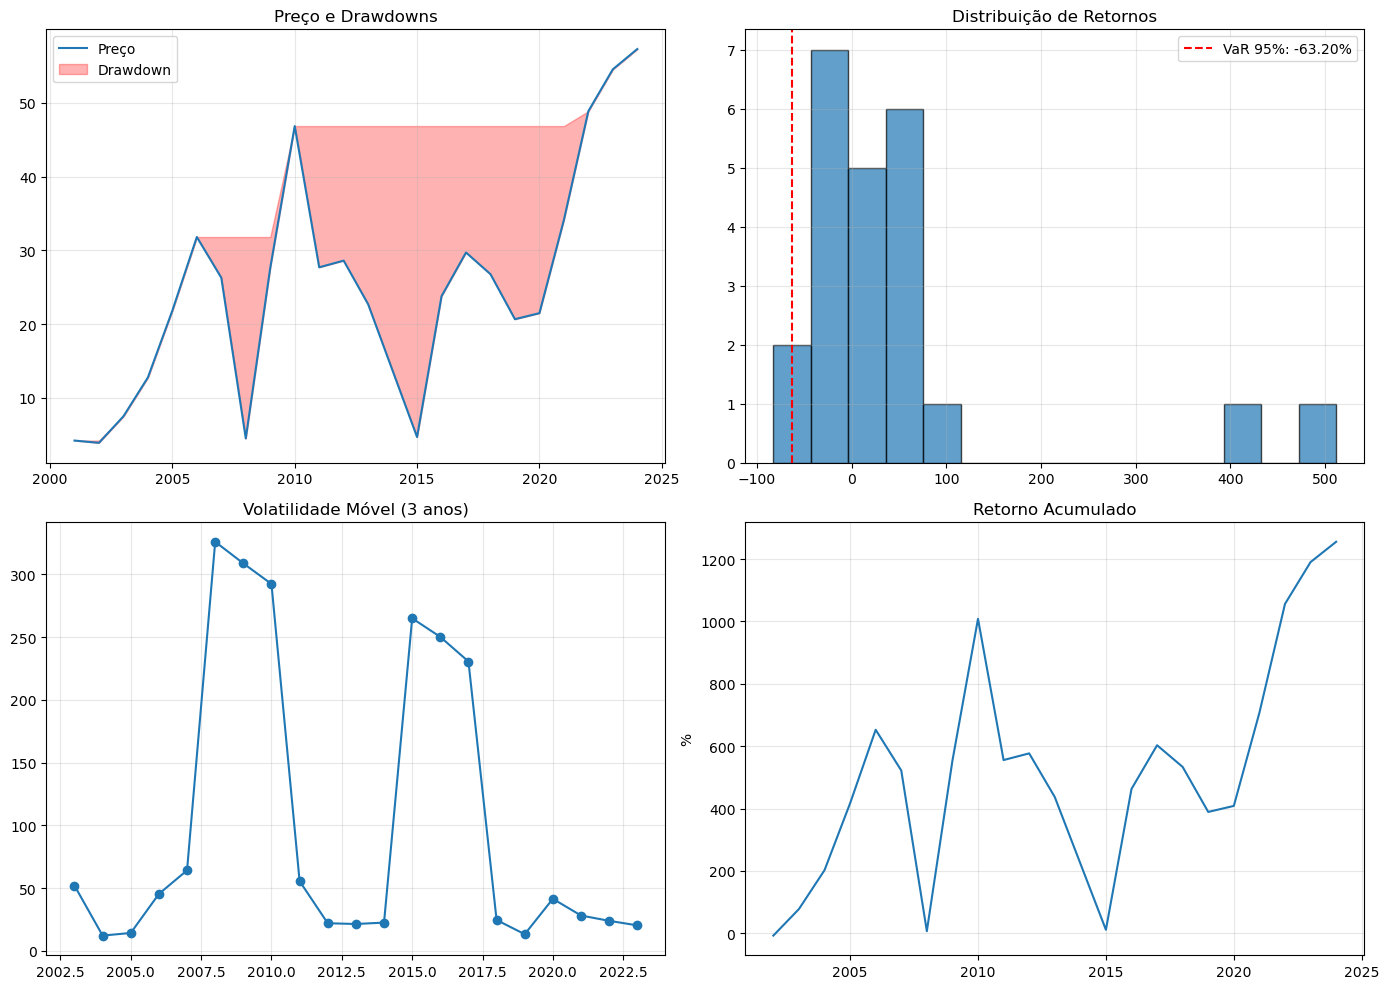


✅ Análise financeira concluída!


In [6]:
"""Visualizações."""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Preço com drawdowns
axes[0,0].plot(df['year'], df['close_price'], label='Preço')
axes[0,0].fill_between(df['year'], prices, cummax, alpha=0.3, color='red', label='Drawdown')
axes[0,0].set_title('Preço e Drawdowns')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Distribuição de retornos
axes[0,1].hist(returns, bins=15, edgecolor='black', alpha=0.7)
axes[0,1].axvline(var_95, color='red', linestyle='--', label=f'VaR 95%: {var_95:.2f}%')
axes[0,1].set_title('Distribuição de Retornos')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Rolling volatility (janela 3 anos)
rolling_vol = pd.Series(returns).rolling(3).std()
# Fix: Convert to numpy arrays and use only non-NaN values
rolling_vol_values = rolling_vol.dropna().values
# Use the corresponding years (skip the first 2 since rolling window of 3 creates 2 NaN values)
year_values = df['year'][2:2+len(rolling_vol_values)].values
axes[1,0].plot(year_values, rolling_vol_values, marker='o')
axes[1,0].set_title('Volatilidade Móvel (3 anos)')
axes[1,0].grid(True, alpha=0.3)

# 4. Cumulative returns
cum_returns = (1 + returns/100).cumprod() - 1
# Fix: Make sure to use the correct range of years that matches cum_returns
year_values_returns = df['year'][1:1+len(cum_returns)].values
axes[1,1].plot(year_values_returns, cum_returns*100)
axes[1,1].set_title('Retorno Acumulado')
axes[1,1].set_ylabel('%')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.OUTPUTS_FIGURES / "financial_analysis.png", dpi=300)
plt.show()

print("\n✅ Análise financeira concluída!")

In [7]:
"""Salvar métricas."""

metrics = pd.DataFrame({
    'Métrica': ['Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown (%)', 
                'VaR 95% (%)', 'CVaR 95% (%)', 'Retorno Médio (%)', 'Volatilidade (%)'],
    'Valor': [sharpe, sortino, max_dd*100, var_95, cvar_95, returns.mean(), returns.std()]
})

metrics.to_csv(config.OUTPUTS_TABLES / "financial_metrics.csv", index=False)
print(f"\n💾 Métricas salvas: {config.OUTPUTS_TABLES / 'financial_metrics.csv'}")


💾 Métricas salvas: C:\Users\user\Documents\_MBA_Data_Science_Analytics\00 - Temas TCC\teck-esge-xai\outputs\tables\financial_metrics.csv
